✅ Semua file berhasil dimuat.
Lokasi dataset: /Users/azzizabdulghofur/Documents/Telkom University/Kompetisi/Lomba/ML-KOMPETISI-INTELLECTRA-2025-IPB/dataset

ANALISIS: Data Anggota (member_data.csv)

Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46401 entries, 0 to 46400
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   MemberID        46401 non-null  object
 1   JoinDate        46401 non-null  object
 2   DateOfBirth     1477 non-null   object
 3   City            46401 non-null  object
 4   NoOfChild       46401 non-null  int64 
 5   EldestKidDOB    46401 non-null  object
 6   YoungestKidDOB  46401 non-null  object
dtypes: int64(1), object(6)
memory usage: 2.5+ MB

Statistik Deskriptif:
                                MemberID    JoinDate DateOfBirth    City  \
count                              46401       46401        1477   46401   
unique                             46401        1622         

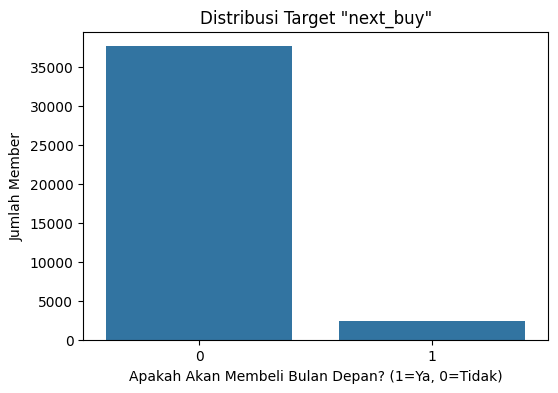


ANALISIS: Data Produk (product_data.csv)

Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   productID        27 non-null     int64 
 1   ProductName      27 non-null     object
 2   ProductCategory  27 non-null     object
 3   ProductLevel     27 non-null     object
dtypes: int64(1), object(3)
memory usage: 996.0+ bytes

Jumlah Nilai Hilang:
productID          0
ProductName        0
ProductCategory    0
ProductLevel       0
dtype: int64

Contoh Data:
   productID        ProductName ProductCategory ProductLevel
0          1                A 3               A     Original
1          2                B 4               B     Original
2          3                A G               A      Premium
3          4                B G               B      Premium
4          9  A G FOR HOME KIOS               A      Premium

ANALISIS: Data Prog

In [23]:
# ==============================================================================
# TAHAP 1: IMPORT LIBRARY DAN MEMUAT DATA
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Mengatur path ke folder dataset dari folder notebooks
# Tanda '..' berarti 'naik satu level direktori'
base_path = '../dataset/'

# Memuat semua dataset yang relevan
try:
    member_df = pd.read_csv(os.path.join(base_path, 'member_data.csv'))
    train_trans_df = pd.read_csv(os.path.join(base_path, 'train_transaction_data.csv'))
    train_label_df = pd.read_csv(os.path.join(base_path, 'train_label_data.csv'))
    product_df = pd.read_csv(os.path.join(base_path, 'product_data.csv'))
    prodgram_df = pd.read_csv(os.path.join(base_path, 'prodgram_data.csv'))
    
    print("✅ Semua file berhasil dimuat.")
    print("Lokasi dataset:", os.path.abspath(base_path))
except FileNotFoundError as e:
    print(f"❌ Gagal memuat file: {e}")
    print("Pastikan file CSV Anda berada di dalam folder 'dataset' dan notebook ini berada di dalam folder 'notebooks'.")

# ==============================================================================
# TAHAP 2: ANALISIS SETIAP TABEL SECARA INDIVIDUAL
# ==============================================================================

print("\n" + "="*50)
print("ANALISIS: Data Anggota (member_data.csv)")
print("="*50)
print("\nInfo Data:")
member_df.info()
print("\nStatistik Deskriptif:")
print(member_df.describe(include='all'))
print("\nJumlah Nilai Hilang:")
print(member_df.isnull().sum())
print("\nContoh Data:")
print(member_df.head())


print("\n" + "="*50)
print("ANALISIS: Data Transaksi Latih (train_transaction_data.csv)")
print("="*50)
print("\nInfo Data:")
train_trans_df.info()
print("\nStatistik Deskriptif:")
print(train_trans_df.describe(include='all'))
print("\nJumlah Nilai Hilang:")
print(train_trans_df.isnull().sum())
print("\nContoh Data:")
print(train_trans_df.head())


print("\n" + "="*50)
print("ANALISIS: Data Label Latih (train_label_data.csv)")
print("="*50)
print("\nInfo Data:")
train_label_df.info()
print("\nJumlah Nilai Hilang:")
print(train_label_df.isnull().sum())
print("\nDistribusi Target (next_buy):")
print(train_label_df['next_buy'].value_counts(normalize=True))
print("\nContoh Data:")
print(train_label_df.head())

# Visualisasi distribusi target
plt.figure(figsize=(6, 4))
sns.countplot(x='next_buy', data=train_label_df)
plt.title('Distribusi Target "next_buy"')
plt.xlabel('Apakah Akan Membeli Bulan Depan? (1=Ya, 0=Tidak)')
plt.ylabel('Jumlah Member')
plt.show()


print("\n" + "="*50)
print("ANALISIS: Data Produk (product_data.csv)")
print("="*50)
print("\nInfo Data:")
product_df.info()
print("\nJumlah Nilai Hilang:")
print(product_df.isnull().sum())
print("\nContoh Data:")
print(product_df.head())


print("\n" + "="*50)
print("ANALISIS: Data Program Produk (prodgram_data.csv)")
print("="*50)
print("\nInfo Data:")
prodgram_df.info()
print("\nJumlah Nilai Hilang:")
print(prodgram_df.isnull().sum())
print("\nContoh Data:")
print(prodgram_df.head())


# ==============================================================================
# TAHAP 3: PENGGABUNGAN DATA AWAL (FIRST MERGE)
# ==============================================================================
print("\n" + "="*50)
print("PENGGABUNGAN DATA AWAL")
print("="*50)

# Menggabungkan data transaksi latih dengan labelnya
train_merged_df = pd.merge(train_trans_df, train_label_df, on='MemberID', how='left')

print("Info data setelah digabung dengan label:")
train_merged_df.info()

print("\nJumlah nilai hilang di kolom 'next_buy' setelah merge:")
print(f"{train_merged_df['next_buy'].isnull().sum()} (Seharusnya 0 jika semua MemberID di data transaksi ada di data label)")

print("\nContoh data gabungan:")
print(train_merged_df.head())

In [24]:
# ==============================================================================
# TAHAP 4: PEMBERSIHAN DAN PERSIAPAN DATA (KODE YANG DIPERBAIKI)
# ==============================================================================
print("Memulai proses pembersihan data...")

# Salin dataframe agar data asli tidak berubah
member_clean = member_df.copy()
train_trans_clean = train_trans_df.copy()
prodgram_clean = prodgram_df.copy()

# --- 1. Mengubah Tipe Data Kolom Tanggal ---
print("\n1. Mengubah tipe data kolom tanggal menjadi datetime...")
date_cols_member = ['JoinDate', 'EldestKidDOB', 'YoungestKidDOB']
# Kita tidak memasukkan 'DateOfBirth' karena akan dihapus
for col in date_cols_member:
    member_clean[col] = pd.to_datetime(member_clean[col], errors='coerce')

train_trans_clean['TransactionDatetime'] = pd.to_datetime(train_trans_clean['TransactionDatetime'])

print("Tipe data member_clean setelah diubah:")
print(member_clean.dtypes)
print("\nTipe data train_trans_clean setelah diubah:")
print(train_trans_clean.dtypes)


# --- 2. Menangani Nilai Hilang (Missing Values) ---
print("\n2. Menangani nilai hilang...")

# 2a. DateOfBirth pada member_data kita drop karena >95% hilang
member_clean = member_clean.drop(columns=['DateOfBirth'])
print("- Kolom 'DateOfBirth' telah dihapus.")

# 2b. PricePerUnit pada data transaksi
# Strategi: Isi dengan harga referensi dari prodgram_data
train_trans_clean = pd.merge(
    train_trans_clean,
    prodgram_clean[['prodgramID', 'Price']],
    left_on='FK_PROD_GRAM_ID',
    right_on='prodgramID',
    how='left'
)

# --- INILAH BAGIAN YANG DIPERBAIKI ---
# Mengisi PricePerUnit yang kosong dengan Price dari prodgram
train_trans_clean['PricePerUnit'] = train_trans_clean['PricePerUnit'].fillna(train_trans_clean['Price'])

# Hapus kolom bantu yang sudah tidak diperlukan
train_trans_clean = train_trans_clean.drop(columns=['prodgramID', 'Price'])
print(f"- Nilai hilang di 'PricePerUnit' setelah diisi dari harga referensi: {train_trans_clean['PricePerUnit'].isnull().sum()}")

# Jika masih ada yg kosong, isi dengan median
if train_trans_clean['PricePerUnit'].isnull().sum() > 0:
    median_price = train_trans_clean['PricePerUnit'].median()
    # --- INILAH BAGIAN KEDUA YANG DIPERBAIKI ---
    train_trans_clean['PricePerUnit'] = train_trans_clean['PricePerUnit'].fillna(median_price)
    print(f"- Mengisi sisa nilai hilang 'PricePerUnit' dengan median ({median_price}).")


# --- 3. Menggabungkan Semua Data Menjadi Satu DataFrame Final ---
print("\n3. Menggabungkan semua tabel menjadi satu DataFrame...")

# Gabungkan data transaksi yang sudah bersih dengan data member
df_train_full = pd.merge(train_trans_clean, member_clean, on='MemberID', how='left')

# Gabungkan dengan data produk
product_df_renamed = product_df.rename(columns={'productID': 'FK_PRODUCT_ID'})
df_train_full = pd.merge(df_train_full, product_df_renamed, on='FK_PRODUCT_ID', how='left')

# Gabungkan dengan data prodgram (untuk info gramasi & poin)
prodgram_df_renamed = prodgram_df.rename(columns={'prodgramID': 'FK_PROD_GRAM_ID'})
df_train_full = pd.merge(df_train_full, prodgram_df_renamed, on='FK_PROD_GRAM_ID', how='left')


print("\n--- DATA BERSIH DAN LENGKAP SIAP UNTUK FEATURE ENGINEERING ---")
print("Info Data Gabungan Final:")
df_train_full.info()

print("\nMemeriksa kembali nilai hilang pada data gabungan:")
# Tampilkan hanya kolom yang masih memiliki nilai hilang
missing_final = df_train_full.isnull().sum()
print(missing_final[missing_final > 0])

Memulai proses pembersihan data...

1. Mengubah tipe data kolom tanggal menjadi datetime...
Tipe data member_clean setelah diubah:
MemberID                  object
JoinDate          datetime64[ns]
DateOfBirth               object
City                      object
NoOfChild                  int64
EldestKidDOB      datetime64[ns]
YoungestKidDOB    datetime64[ns]
dtype: object

Tipe data train_trans_clean setelah diubah:
TransactionID                       object
MemberID                            object
Source                              object
FK_PRODUCT_ID                        int64
FK_PROD_GRAM_ID                      int64
Qty                                  int64
PricePerUnit                       float64
TransactionDatetime    datetime64[ns, UTC]
dtype: object

2. Menangani nilai hilang...
- Kolom 'DateOfBirth' telah dihapus.
- Nilai hilang di 'PricePerUnit' setelah diisi dari harga referensi: 0

3. Menggabungkan semua tabel menjadi satu DataFrame...

--- DATA BERSIH DAN LENGKA

In [25]:
# ==============================================================================
# STRATEGI FINAL: FITUR BERBASIS SIKLUS KONSUMSI (GRAMASI)
# ==============================================================================
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import balanced_accuracy_score, classification_report

print("Memulai proses dengan STRATEGI FINAL: FITUR KONSUMSI...")

# --- 1. Persiapan Data Dasar ---
# Muat ulang semua data untuk memastikan kebersihan
train_trans_df = pd.read_csv('../dataset/train_transaction_data.csv')
test_trans_df = pd.read_csv('../dataset/test_transaction_data.csv')
prodgram_df = pd.read_csv('../dataset/prodgram_data.csv')
train_label_df = pd.read_csv('../dataset/train_label_data.csv')

# --- 2. Feature Engineering pada Level Transaksi ---
# Ekstrak nilai gramasi numerik dari nama
prodgram_df['GrammageNumeric'] = prodgram_df['GrammageName'].str.extract('(\d+)').astype(float)
# Isi nilai yang mungkin kosong dengan nilai median
prodgram_df['GrammageNumeric'].fillna(prodgram_df['GrammageNumeric'].median(), inplace=True)

# Gabungkan semua data transaksi
all_trans_df = pd.concat([train_trans_df, test_trans_df], ignore_index=True)
all_trans_df['TransactionDatetime'] = pd.to_datetime(all_trans_df['TransactionDatetime']).dt.tz_localize(None)

# Gabungkan dengan data prodgram untuk mendapatkan gramasi
all_trans_df = pd.merge(all_trans_df, prodgram_df[['prodgramID', 'GrammageNumeric']], left_on='FK_PROD_GRAM_ID', right_on='prodgramID', how='left')

# Hitung 'TotalGrammage' sebagai sinyal konsumsi utama
all_trans_df['TotalGrammage'] = all_trans_df['Qty'] * all_trans_df['GrammageNumeric']
all_trans_df['Month'] = all_trans_df['TransactionDatetime'].dt.to_period('M')
print("- Fitur 'TotalGrammage' sebagai sinyal konsumsi telah dibuat.")

# --- 3. Membuat Agregat Bulanan Berbasis Konsumsi & Frekuensi ---
monthly_agg = all_trans_df.groupby(['MemberID', 'Month']).agg(
    TotalGrammage=('TotalGrammage', 'sum'),
    Frequency=('TransactionID', 'nunique') # Hitung jumlah kunjungan unik
).reset_index()
print("- Agregat konsumsi & frekuensi bulanan telah dibuat.")

# --- 4. Membuat "Kanvas" Data Latih (Point-in-Time) ---
all_months = monthly_agg['Month'].unique()
all_members = all_trans_df['MemberID'].unique()
canvas_df = pd.MultiIndex.from_product([all_members, all_months], names=['MemberID', 'Month']).to_frame(index=False)
data = pd.merge(canvas_df, monthly_agg, on=['MemberID', 'Month'], how='left').fillna(0)
data = data.sort_values(by=['MemberID', 'Month'])

# --- 5. Membuat Lag & Rolling Features untuk Gramasi dan Frekuensi ---
features_to_lag = ['TotalGrammage', 'Frequency']
lags = [1, 2, 3]
windows = [3, 6]

for feat in features_to_lag:
    for lag in lags:
        data[f'{feat}_lag_{lag}'] = data.groupby('MemberID')[feat].shift(lag).fillna(0)
    for window in windows:
        data[f'{feat}_rolling_mean_{window}'] = data.groupby('MemberID')[feat].shift(1).rolling(window, min_periods=1).mean().fillna(0)
        data[f'{feat}_rolling_std_{window}'] = data.groupby('MemberID')[feat].shift(1).rolling(window, min_periods=1).std().fillna(0)
print("- Fitur Lag dan Rolling Window untuk Konsumsi & Frekuensi telah dibuat.")

# --- 6. Membuat Label Target ---
data['target'] = data.groupby('MemberID')['TotalGrammage'].shift(-1).fillna(0)
data['target'] = (data['target'] > 0).astype(int)
data = data.groupby('MemberID').head(-1) # Hapus bulan terakhir
print("- Label target telah dibuat.")

# --- 7. Validasi Berbasis Waktu ---
# Tentukan bulan terakhir di data sebagai set validasi
# Kita hanya gunakan data latih untuk validasi
train_member_ids = train_label_df['MemberID'].unique()
train_data_full = data[data['MemberID'].isin(train_member_ids)]

validation_month = train_data_full['Month'].max()
train_df = train_data_full[train_data_full['Month'] < validation_month]
val_df = train_data_full[train_data_full['Month'] == validation_month]

features = [col for col in data.columns if col not in ['MemberID', 'Month', 'TotalGrammage', 'Frequency', 'target']]
X_train = train_df[features]
y_train = train_df['target']
X_val = val_df[features]
y_val = val_df['target']

print(f"\nVALIDASI BERBASIS WAKTU: Bulan validasi: {validation_month}")
print(f"Data latih: {len(X_train)} baris, Data validasi: {len(X_val)} baris")

# --- 8. Pelatihan dan Evaluasi Model ---
if not y_train.empty and len(y_train.value_counts()) > 1:
    print("\nMelatih model LightGBM dengan fitur berbasis konsumsi...")
    scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
    lgbm = lgb.LGBMClassifier(objective='binary', scale_pos_weight=scale_pos_weight, random_state=42, verbose=-1)
    lgbm.fit(X_train, y_train)
    y_pred = lgbm.predict(X_val)
    balanced_acc = balanced_accuracy_score(y_val, y_pred)
    print(f"\n================================================")
    print(f"🏆 Balanced Accuracy Score (Strategi Konsumsi): {balanced_acc:.4f}")
    print(f"================================================")
    print("\nLaporan Klasifikasi:")
    print(classification_report(y_val, y_pred))
else:
    print("\nTidak dapat melatih model, data latih atau validasi kosong atau hanya memiliki satu kelas.")

Memulai proses dengan STRATEGI FINAL: FITUR KONSUMSI...


/var/folders/ry/hms3_4ls6p79dg7124kj0lvw0000gn/T/ipykernel_14346/490607158.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  prodgram_df['GrammageNumeric'].fillna(prodgram_df['GrammageNumeric'].median(), inplace=True)


- Fitur 'TotalGrammage' sebagai sinyal konsumsi telah dibuat.
- Agregat konsumsi & frekuensi bulanan telah dibuat.
- Fitur Lag dan Rolling Window untuk Konsumsi & Frekuensi telah dibuat.
- Label target telah dibuat.

VALIDASI BERBASIS WAKTU: Bulan validasi: 2021-05
Data latih: 400200 baris, Data validasi: 40020 baris

Melatih model LightGBM dengan fitur berbasis konsumsi...

🏆 Balanced Accuracy Score (Strategi Konsumsi): 0.7210

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.97      0.58      0.73     36005
           1       0.19      0.86      0.31      4015

    accuracy                           0.61     40020
   macro avg       0.58      0.72      0.52     40020
weighted avg       0.90      0.61      0.68     40020



In [26]:
# ==============================================================================
# TAHAP 8: FINAL SUBMISSION (STRATEGI KONSUMSI)
# ==============================================================================
print("--- Memulai Proses Pembuatan Submission dengan Strategi Konsumsi ---")

# --- 1. Persiapan Data Latih Final ---
# Kita gunakan semua data latih yang sudah diproses (tanpa pemisahan validasi)
# untuk melatih model yang lebih kuat.
X_full_train = train_data_full[features]
y_full_train = train_data_full['target']

print(f"1. Melatih model final pada {len(X_full_train)} baris data latih...")
# Hitung class weight dari seluruh data latih
final_scale_pos_weight = y_full_train.value_counts()[0] / y_full_train.value_counts()[1]

# Inisialisasi dan latih model final
final_lgbm = lgb.LGBMClassifier(
    objective='binary',
    scale_pos_weight=final_scale_pos_weight,
    random_state=42,
    verbose=-1
    # Anda bisa tambahkan best_params dari Optuna di sini jika sudah menjalankannya
)
final_lgbm.fit(X_full_train, y_full_train)
print("Model final berhasil dilatih.")


# --- 2. Memproses Data Tes ---
print("\n2. Memproses data tes...")
# Kita perlu fitur dari bulan terakhir yang tersedia di data untuk setiap member tes
# Bulan terakhir di 'data' adalah data fitur terbaru kita
latest_features_df = data.loc[data.groupby('MemberID')['Month'].idxmax()]

# Ambil kerangka submission untuk memastikan kita hanya memprediksi member yang diminta
sample_submission_df = pd.read_csv('../submission/sample_submission.csv')
final_test_df = pd.merge(sample_submission_df[['MemberID']], latest_features_df, on='MemberID', how='left')

# Isi nilai yang mungkin hilang (jika member tes tidak punya histori sama sekali)
final_test_df.fillna(0, inplace=True)
print("Data tes berhasil diproses.")

# --- 3. Membuat Prediksi dan Menyimpan File ---
print("\n3. Membuat prediksi pada data tes...")
# Pastikan urutan kolom sama persis dengan data latih
X_test_final = final_test_df[features] 
test_predictions = final_lgbm.predict(X_test_final)

# Buat DataFrame submission
submission_df = pd.DataFrame({
    'MemberID': final_test_df['MemberID'],
    'next_buy': test_predictions
})

# Simpan ke file CSV
submission_df.to_csv('../submission/submissionV8.csv', index=False)

print("\n🎉 File 'submission_konsumsi.csv' telah berhasil dibuat di folder 'submissions'!")
print("Ini adalah submission terbaik kita sejauh ini. Semoga berhasil!")
print(submission_df.head())
print("\nJumlah prediksi 'Beli' (1):", submission_df['next_buy'].sum())

--- Memulai Proses Pembuatan Submission dengan Strategi Konsumsi ---
1. Melatih model final pada 440220 baris data latih...
Model final berhasil dilatih.

2. Memproses data tes...
Data tes berhasil diproses.

3. Membuat prediksi pada data tes...

🎉 File 'submission_konsumsi.csv' telah berhasil dibuat di folder 'submissions'!
Ini adalah submission terbaik kita sejauh ini. Semoga berhasil!
                           MemberID  next_buy
0  c2a630e3d0dc77dac0f63424a9ae1438         0
1  3ecf7484c08418953e967a20de37051b         0
2  97bbd6c99a862f20657d9b2b1c77b2c8         1
3  3ce072ff9c6f2f4b7c95dbc08324a24d         0
4  ab0b0de2a1c85a40b5d58644aef745c0         1

Jumlah prediksi 'Beli' (1): 2901
